<a href="https://colab.research.google.com/github/AhsanullahCS/FlyRank_Internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AhsanullahCS/FlyRank_Internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method Choice and Why

This project is a binary classification problem: predicting whether a customer will churn.

I compared several classification methods from the available toolkit, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

I selected Logistic Regression as the main model because it is appropriate for binary classification, relatively simple, and interpretable. It also provides a useful benchmark for understanding which customer features are associated with churn.

I also compare the other models to check whether additional model complexity provides a meaningful improvement over the simpler approach.

The main evaluation metrics are accuracy, precision, recall, F1 score, and ROC-AUC. Because churn prediction focuses on identifying customers who may leave, recall and F1 score are particularly useful alongside accuracy.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

## 2. Split Design

The target variable is `Churn`, which indicates whether a customer left the service.

I use a stratified train/test split so that the proportion of churn and non-churn customers is approximately preserved in both sets.

The test set is kept separate from model training and is used only for final evaluation.

This makes the comparison more honest because all candidate models are evaluated on the same unseen test customers.

In [8]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["MonthlyCharges"] * df["tenure"]
)

# Feature engineering
df["AverageMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# Remove identifier
df = df.drop("customerID", axis=1)

# Convert target
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining churn rate:")
print(y_train.mean())

print("\nTesting churn rate:")
print(y_test.mean())

Training shape: (5634, 20)
Testing shape: (1409, 20)

Training churn rate:
0.2653532126375577

Testing churn rate:
0.2654364797728886


In [9]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend"
]

categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_columns
        )
    ]
)

## 3. Train + Compare vs My Baseline

I train several classification models using the same training data and evaluate them on the same test set.

The models are compared using the same evaluation metrics as the Week-4 baseline.

The purpose is not to choose the most complex model automatically, but to determine whether the models provide a meaningful improvement over the baseline.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8421
1,Decision Tree,0.7402,0.5107,0.5107,0.5107,0.6687
2,Random Forest,0.7892,0.6323,0.4920,0.5534,0.8251
3,Gradient Boosting,0.7942,0.6489,0.4893,0.5579,0.8423


### Logistic Regression Tuning

Logistic Regression was selected for further tuning because it provided a strong combination of performance and interpretability.

I used cross-validation to search over regularization strength, class weighting, penalty, and solver settings.

The goal was to improve the balance between precision and recall rather than simply maximizing accuracy.

In [11]:
from sklearn.model_selection import GridSearchCV

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)
best_model = grid_search.best_estimator_

tuned_predictions = best_model.predict(X_test)
tuned_probabilities = best_model.predict_proba(X_test)[:, 1]

tuned_results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, tuned_predictions),
    "Precision": precision_score(y_test, tuned_predictions),
    "Recall": recall_score(y_test, tuned_predictions),
    "F1": f1_score(y_test, tuned_predictions),
    "ROC-AUC": roc_auc_score(y_test, tuned_probabilities)
}

tuned_results

Best Parameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best CV F1:
0.6329199059787011


{'Model': 'Tuned Logistic Regression',
 'Accuracy': 0.7388218594748048,
 'Precision': 0.5051546391752577,
 'Recall': 0.786096256684492,
 'F1': 0.6150627615062761,
 'ROC-AUC': np.float64(0.8418765661732415)}

## 4. Errors and Interpretation

The model does not make every prediction correctly, so I examine the confusion matrix to understand the types of errors.

For churn prediction, false negatives are important because they represent customers who actually churned but were predicted not to churn.

The tuned Logistic Regression model increased recall compared with the untuned model, meaning it identified more actual churners. However, this came with lower precision and accuracy.

This shows a trade-off between identifying more potential churners and avoiding false alarms.

The results should therefore be treated as decision-support rather than as a perfect prediction of customer behavior.

In [12]:
cm = confusion_matrix(
    y_test,
    tuned_predictions
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["No Churn", "Churn"]
    )
)
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

Confusion Matrix:
[[747 288]
 [ 80 294]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

True Negatives : 747
False Positives: 288
False Negatives: 80
True Positives  : 294


In [13]:
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    best_model
    .named_steps["model"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,AbsoluteCoefficient
26,cat__Contract_Two year,-1.414180,1.414180
1,num__tenure,-1.155390,1.155390
11,cat__InternetService_Fiber optic,1.112521,1.112521
25,cat__Contract_One year,-0.720296,0.720296
3,num__TotalCharges,0.487892,0.487892
2,num__MonthlyCharges,-0.455455,0.455455
29,cat__PaymentMethod_Electronic check,0.397039,0.397039
8,cat__PhoneService_Yes,-0.393133,0.393133
24,cat__StreamingMovies_Yes,0.378421,0.378421
14,cat__OnlineSecurity_Yes,-0.357025,0.357025


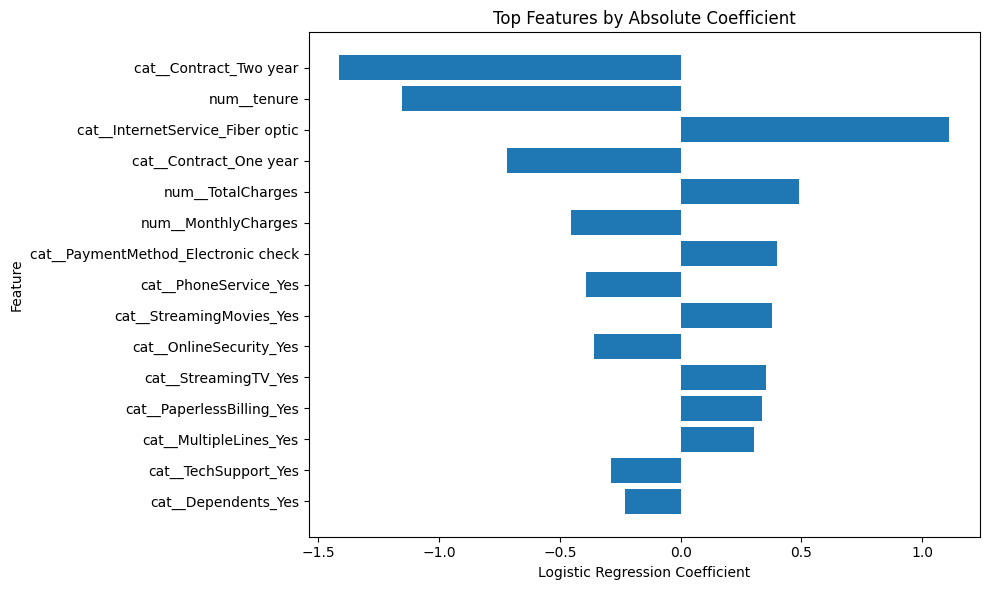

In [14]:
top_features = feature_importance.head(15).sort_values(
    "AbsoluteCoefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features by Absolute Coefficient")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.